In [ ]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="password",
    database="irrigation_db"
)
cursor = conn.cursor()


fieldids = [2, 4 , 5, 6]
zones = ['s_w', 's_b']

for fieldid in fieldids:
    for zone in zones:

        df = pd.read_csv(f'../data/csv_files/field_f{fieldid}', usecols=['datetime', zone])
        # Convert to datetime if needed
        df['datetime'] = pd.to_datetime(df['datetime'])
        # Add 1 year (assign back to column)
        df['datetime'] = df['datetime'] + pd.DateOffset(years=1)

        sql = "INSERT INTO soil_moisture (ts, water_content, field_id, sensor_zone) VALUES (%s, %s, %s, %s)"

        data = [tuple(list(row)+[fieldid, zone]) for _, row in df[["datetime", zone
                                                                   ]].iterrows()]
        cursor.executemany(sql, data)

        conn.commit()

cursor.close()

conn.close()


In [ ]:
# 'datetime', 's_b', 's_w', 'LAI', 'irr'
df = pd.read_csv(f'../data/csv_files/field_f2', usecols=['datetime', 's_b', 's_w', 'LAI', 'irr'])
df[df['irr']>0][['datetime','irr']]

In [12]:
df.head()

,datetime,s_b,s_w,LAI,irr
0,2024-12-12 12:00:00,13.93,11.12,0.000000,0.0
1,2024-12-12 13:00:00,13.89,11.07,0.000088,0.0
2,2024-12-12 14:00:00,13.91,11.10,0.000175,0.0
3,2024-12-12 15:00:00,13.95,11.18,0.000263,0.0
4,2024-12-12 16:00:00,13.98,11.21,0.000351,0.0


In [14]:
df[df['irr']>0][['datetime','irr']]

,datetime,irr
1776,2025-02-24 12:00:00,18.238994
2280,2025-03-17 12:00:00,24.528302
2496,2025-03-26 12:00:00,42.070000
2664,2025-04-02 12:00:00,40.060000
2784,2025-04-07 12:00:00,39.040000
2880,2025-04-11 12:00:00,36.070000
3120,2025-04-21 12:00:00,35.360000


In [187]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="password",
    database="irrigation_db"
)
cursor = conn.cursor()


fieldids = [2, 4 , 5, 6]

for fieldid in fieldids:
    df = pd.read_csv(f'../data/csv_files/field_f{fieldid}', usecols=['datetime', 'irr'])
    df = df[df['irr']>0]
    # Convert to datetime if needed
    df['datetime'] = pd.to_datetime(df['datetime'])
    # Add 1 year (assign back to column)
    df['datetime'] = df['datetime'] + pd.DateOffset(years=1)
    dfirr = df[df['irr']>0]
    sql = "INSERT INTO irrigation (ts, water_volume, field_id) VALUES (%s, %s, %s)"

    data = [tuple(list(row)+[fieldid]) for _, row in df[["datetime", 'irr']].iterrows()]
    cursor.executemany(sql, data)
    conn.commit()

cursor.close()
conn.close()


In [145]:
df = pd.read_excel('../db/LAI_Morocco_Season1.xlsx', sheet_name=f'Sheet1')
df["datetime"] = pd.to_datetime(df["datetime"]) + pd.to_timedelta("12:00:00")
df['datetime'] = df['datetime'] + pd.DateOffset(years=1)
df.head()

,datetime,Tititcaca-CROP,Tititcaca-Sensor,Tititcaca-Farmer,ICBA-CROP,ICBA-Sensor,ICBA-Farmer
0,2026-01-01 12:00:00,0.09,0.09,0.09,0.09,0.09,0.09
1,2027-01-15 12:00:00,0.12,0.12,0.12,0.12,0.12,0.12
2,2027-01-31 12:00:00,0.20,0.20,0.20,0.20,0.20,0.20
3,2026-02-07 12:00:00,0.65,0.12,0.25,0.74,0.37,0.21
4,2026-02-13 12:00:00,0.62,0.65,0.50,0.56,0.60,0.52


In [146]:

values = {
    "datetime": "2025-12-12 12:00:00",
    "Tititcaca-CROP": 0,
    "Tititcaca-Sensor": 0,
    "Tititcaca-Farmer": 0,
    "ICBA-CROP": 0,
    "ICBA-Sensor": 0,
    "ICBA-Farmer": 0
}
df.loc[10] = values


In [188]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="password",
    database="irrigation_db"
)
cursor = conn.cursor()

fieldids = [2, 4 , 5, 6]
fieldCodes = ['Tititcaca-Sensor', 'ICBA-Sensor', 'Tititcaca-Farmer', 'ICBA-Farmer']

for fieldid, fcode in zip(fieldids, fieldCodes):
    df = pd.read_excel('../db/LAI_Morocco_Season1.xlsx', sheet_name=f'Sheet1')
    df["datetime"] = pd.to_datetime(df["datetime"]) + pd.to_timedelta("12:00:00")
    # Add 1 year (assign back to column)
    df['datetime'] = df['datetime'] + pd.DateOffset(years=1)
    values = {
        "datetime": "2025-12-12 12:00:00",
        "Tititcaca-CROP": 0,
        "Tititcaca-Sensor": 0,
        "Tititcaca-Farmer": 0,
        "ICBA-CROP": 0,
        "ICBA-Sensor": 0,
        "ICBA-Farmer": 0
    }
    df.loc[10] = values
    
    sql = "INSERT INTO lai (ts, lai, field_id) VALUES (%s, %s, %s)"

    data = [tuple(list(row)+[fieldid]) for _, row in df[["datetime", fcode]].iterrows()]
    cursor.executemany(sql, data)
    conn.commit()

cursor.close()
conn.close()
    



In [ ]:
from datetime import datetime, timedelta


def get_start_end_date(delta, direction):
    now = datetime.now()
    date_now = pd.to_datetime(now)
    date_now_round = date_now.round("h")
    # print(str(date_now_round))
    if direction == "past":
        end_dt = str(date_now_round)
        start_dt = str(date_now_round - timedelta(hours=delta - 1))
    if direction == "future":
        start_dt = str(date_now_round + timedelta(hours=1))
        end_dt = str(date_now_round + timedelta(hours=delta))

    return (start_dt, end_dt)

## Retieval cost

In [148]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="password",
    database="irrigation_db"
)
cursor = conn.cursor()



# query = f"""
# SELECT ts, lai
# FROM lai
# WHERE ts < CURDATE() AND field_id = 2
# ORDER BY ts ASC;
# """
query = f"""
SELECT ts, lai
FROM lai
WHERE ts < '2026-03-15' AND field_id = 2
ORDER BY ts ASC;
"""

cursor.execute(query)
rows = cursor.fetchall()

cursor.close()
conn.close()

print(rows)

[(datetime.datetime(2025, 12, 12, 12, 0), 0.0), (datetime.datetime(2026, 1, 1, 12, 0), 0.09), (datetime.datetime(2026, 2, 7, 12, 0), 0.12), (datetime.datetime(2026, 2, 13, 12, 0), 0.65), (datetime.datetime(2026, 2, 20, 12, 0), 0.75), (datetime.datetime(2026, 2, 27, 12, 0), 1.17), (datetime.datetime(2026, 3, 6, 12, 0), 1.68), (datetime.datetime(2026, 3, 13, 12, 0), 2.44)]


In [149]:
start_dt, end_dt = get_start_end_date(48, 'past')
print(start_dt, end_dt)

2026-01-11 12:00:00 2026-01-13 11:00:00


<Axes: >

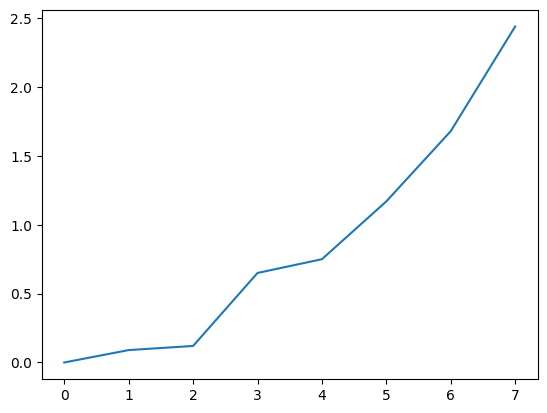

In [159]:
df = pd.DataFrame(rows, columns=['ts','lai'])
df["ts"] = pd.to_datetime(df["ts"])
df['lai'].plot()

In [153]:
df

,ts,lai
0,2025-12-12 12:00:00,0.00
1,2026-01-01 12:00:00,0.09
2,2026-02-07 12:00:00,0.12
3,2026-02-13 12:00:00,0.65
4,2026-02-20 12:00:00,0.75
5,2026-02-27 12:00:00,1.17
6,2026-03-06 12:00:00,1.68
7,2026-03-13 12:00:00,2.44


In [160]:
full_index = pd.date_range(start=df['ts'][0], end=end_dt, freq="h")
df = df.set_index("ts")



In [161]:
df = df.reindex(full_index)
df['lai'] = df['lai'].interpolate()

In [162]:
df

,lai
2025-12-12 12:00:00,0.000000
2025-12-12 13:00:00,0.000188
2025-12-12 14:00:00,0.000375
2025-12-12 15:00:00,0.000563
2025-12-12 16:00:00,0.000750
...,...
2026-01-13 07:00:00,0.090000
2026-01-13 08:00:00,0.090000
2026-01-13 09:00:00,0.090000
2026-01-13 10:00:00,0.090000


In [163]:
filtered_df = df.loc[start_dt: end_dt]
filtered_df['lai']

2026-01-11 12:00:00    0.09
2026-01-11 13:00:00    0.09
2026-01-11 14:00:00    0.09
2026-01-11 15:00:00    0.09
2026-01-11 16:00:00    0.09
2026-01-11 17:00:00    0.09
2026-01-11 18:00:00    0.09
2026-01-11 19:00:00    0.09
2026-01-11 20:00:00    0.09
2026-01-11 21:00:00    0.09
2026-01-11 22:00:00    0.09
2026-01-11 23:00:00    0.09
2026-01-12 00:00:00    0.09
2026-01-12 01:00:00    0.09
2026-01-12 02:00:00    0.09
2026-01-12 03:00:00    0.09
2026-01-12 04:00:00    0.09
2026-01-12 05:00:00    0.09
2026-01-12 06:00:00    0.09
2026-01-12 07:00:00    0.09
2026-01-12 08:00:00    0.09
2026-01-12 09:00:00    0.09
2026-01-12 10:00:00    0.09
2026-01-12 11:00:00    0.09
2026-01-12 12:00:00    0.09
2026-01-12 13:00:00    0.09
2026-01-12 14:00:00    0.09
2026-01-12 15:00:00    0.09
2026-01-12 16:00:00    0.09
2026-01-12 17:00:00    0.09
2026-01-12 18:00:00    0.09
2026-01-12 19:00:00    0.09
2026-01-12 20:00:00    0.09
2026-01-12 21:00:00    0.09
2026-01-12 22:00:00    0.09
2026-01-12 23:00:00 

In [166]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="password",
    database="irrigation_db"
)
cursor = conn.cursor()

zones = {'s_b', 's_w'}

outSensor = {}
for zone in zones:
    query = f"""
    SELECT ts, water_content
    FROM soil_moisture
    WHERE sensor_zone = '{zone}' and ts BETWEEN %s AND %s AND field_id = 2;
    """

    cursor.execute(query, (start_dt, end_dt))
    rows = cursor.fetchall()
    outSensor[zone] = rows

cursor.close()
conn.close()

print(outSensor)

{'s_w': [(datetime.datetime(2026, 1, 11, 12, 0), 20.75), (datetime.datetime(2026, 1, 11, 13, 0), 20.74), (datetime.datetime(2026, 1, 11, 14, 0), 20.73), (datetime.datetime(2026, 1, 11, 15, 0), 20.72), (datetime.datetime(2026, 1, 11, 16, 0), 20.71), (datetime.datetime(2026, 1, 11, 17, 0), 20.71), (datetime.datetime(2026, 1, 11, 18, 0), 20.7), (datetime.datetime(2026, 1, 11, 19, 0), 20.7), (datetime.datetime(2026, 1, 11, 20, 0), 20.69), (datetime.datetime(2026, 1, 11, 21, 0), 20.7), (datetime.datetime(2026, 1, 11, 22, 0), 20.7), (datetime.datetime(2026, 1, 11, 23, 0), 20.7), (datetime.datetime(2026, 1, 12, 0, 0), 20.7), (datetime.datetime(2026, 1, 12, 1, 0), 20.68), (datetime.datetime(2026, 1, 12, 2, 0), 20.65), (datetime.datetime(2026, 1, 12, 3, 0), 20.64), (datetime.datetime(2026, 1, 12, 4, 0), 20.61), (datetime.datetime(2026, 1, 12, 5, 0), 20.61), (datetime.datetime(2026, 1, 12, 6, 0), 20.61), (datetime.datetime(2026, 1, 12, 7, 0), 20.61), (datetime.datetime(2026, 1, 12, 8, 0), 20.6),

In [181]:
df = pd.DataFrame(outSensor['s_w'], columns=['ts','water_content'])
df["ts"] = pd.to_datetime(df["ts"])
df["ts"] = df["ts"].dt.round('h')
df = df.groupby('ts').mean()
df.head()

,water_content
ts,
2026-01-11 12:00:00,20.75
2026-01-11 13:00:00,20.74
2026-01-11 14:00:00,20.73
2026-01-11 15:00:00,20.72
2026-01-11 16:00:00,20.71


In [182]:
full_index = pd.date_range(start=start_dt, end=end_dt, freq="h")
df = df.reindex(full_index)
df = df.interpolate()

In [183]:
df

,water_content
2026-01-11 12:00:00,20.75
2026-01-11 13:00:00,20.74
2026-01-11 14:00:00,20.73
2026-01-11 15:00:00,20.72
2026-01-11 16:00:00,20.71
2026-01-11 17:00:00,20.71
2026-01-11 18:00:00,20.70
2026-01-11 19:00:00,20.70
2026-01-11 20:00:00,20.69
2026-01-11 21:00:00,20.70


In [192]:
len(full_index) * [0.0]

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [209]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="password",
    database="irrigation_db"
)
cursor = conn.cursor()

query = f"""
SELECT ts, water_volume
FROM irrigation
WHERE ts BETWEEN '2026-03-17 12:00:00' AND '2026-04-07 12:00:00' AND field_id = 2;
"""

cursor.execute(query)#, (start_dt, end_dt))
rows = cursor.fetchall()
rows

if len(rows)==0:
    irr = len(full_index) * [0.0]
else:
    df = pd.DataFrame(rows, columns=['ts', 'water_volume'])
    df["ts"] = pd.to_datetime(df["ts"])
    full_index = pd.date_range(start=start_dt, end=end_dt, freq="h")
    df = df.set_index('ts')
    df = df.reindex(full_index)
    df.fillna(0.0, inplace=True)
    print(df['water_volume'].to_list())



[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [215]:
str(full_index.to_list()[0])

'2026-01-11 12:00:00'